
# 05. Targeted GB Intervention under Feature Noise and Missingness

This notebook keeps the comparison narrow and purposeful.

- **Input:** the Gradient Boosting family selected earlier as the most promising model line.
- **Question:** which targeted training design gives the best **clean–robustness trade-off**?
- **Compared variants:** baseline, noise augmentation, feature-group masking, and a **coupled hybrid** that mixes feature noise with structured feature missingness in the same augmented copies.

The goal is **not** to force an intervention to win. The goal is to give the interventions a *fairer design*: lighter augmentation, explicit missing-group indicators, and a hybrid that actually combines the two stress types.


In [1]:

from pathlib import Path
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

for p in [PROJECT_ROOT, SRC_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

from stress_utils import make_train_valid_split
from stress_protocol import run_clean_benchmark, run_all_models_stress_suite
from robust_score import build_robust_summary
from interventions import get_gb_feature_missing_variants


In [2]:

train_processed = pd.read_csv(DATA_DIR / "train_processed.csv")

X = train_processed.drop("SalePrice_log", axis=1).copy()
y = train_processed["SalePrice_log"].copy()

X_train, X_valid, y_train, y_valid = make_train_valid_split(
    X, y, test_size=0.2, random_state=42
)

robust_summary_04 = pd.read_csv(TABLE_DIR / "stress_benchmark_robust_summary.csv")
champion_04 = pd.read_csv(TABLE_DIR / "stress_benchmark_champion_model.csv")

print("Previous-stage champion:")
display(champion_04)
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)


Previous-stage champion:


,rank,model,clean_rmse,clean_mae,clean_r2,feature_ablation,feature_noise,target_corruption,worst_group_rmse,best_group_rmse,mean_group_rmse,worst_group_gap,robust_penalty_raw,RobustScore,joint_rank_score
0,1,GradientBoosting,0.110588,0.074016,0.918985,0.001818,0.000015,0.000086,0.149683,0.080863,0.105893,0.039096,0.010517,-0.010517,-0.97102


X_train shape: (1160, 275)
X_valid shape: (291, 275)



## Stress axes and GB variants

The stress axes stay aligned with the earlier benchmark so the comparison remains fair.

The interventions are slightly **lighter** than the previous version:
- noise augmentation uses a subset of rows instead of a full extra noisy copy,
- feature masking uses a subset of rows and lower augmentation weight,
- the hybrid now applies **noise + feature masking together** in the same augmented copies.


In [3]:

noise_cols = [
    c for c in ["GrLivArea", "TotalSF", "LotArea", "HouseAge", "TotalBath"]
    if c in X_train.columns
]

feature_groups = {
    "size": ["GrLivArea", "TotalSF", "1stFlrSF", "2ndFlrSF", "LotArea"],
    "quality": ["OverallQual", "OverallCond", "KitchenQual", "ExterQual"],
    "age": ["HouseAge", "YearBuilt", "YearRemodAdd", "GarageAge", "YearsSinceRemod"],
}

noise_scales = (0.01, 0.03, 0.05)
target_scales = (0.03,)
target_frac = 0.10

variants = get_gb_feature_missing_variants(
    noise_cols=noise_cols,
    feature_groups=feature_groups,
    random_state=42,
)

print("noise_cols:", noise_cols)
print("feature_groups:", feature_groups)
print("variants:", list(variants.keys()))


noise_cols: ['GrLivArea', 'TotalSF', 'LotArea', 'HouseAge', 'TotalBath']
feature_groups: {'size': ['GrLivArea', 'TotalSF', '1stFlrSF', '2ndFlrSF', 'LotArea'], 'quality': ['OverallQual', 'OverallCond', 'KitchenQual', 'ExterQual'], 'age': ['HouseAge', 'YearBuilt', 'YearRemodAdd', 'GarageAge', 'YearsSinceRemod']}
variants: ['GB_Baseline', 'GB_NoiseAug', 'GB_FeatureMask', 'GB_NoisePlusFeatureMask']


In [4]:

clean_variant_df, fitted_variant_models = run_clean_benchmark(
    models=variants,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
)

clean_variant_df = clean_variant_df.rename(
    columns={"rmse": "clean_rmse", "mae": "clean_mae", "r2": "clean_r2"}
)
clean_variant_df.to_csv(TABLE_DIR / "gb_variant_clean_holdout.csv", index=False)
clean_variant_df.sort_values("clean_rmse")


,model,test,clean_rmse,clean_mae,clean_r2
0,GB_Baseline,clean,0.110983,0.073427,0.918405
1,GB_NoiseAug,clean,0.111761,0.074424,0.917258
2,GB_FeatureMask,clean,0.113082,0.075378,0.915289
3,GB_NoisePlusFeatureMask,clean,0.118190,0.078713,0.907463


In [5]:

stress_variant_long_df, subgroup_variant_long_df = run_all_models_stress_suite(
    models=variants,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    noise_cols=noise_cols,
    feature_groups=feature_groups,
    noise_scales=noise_scales,
    target_scales=target_scales,
    target_frac=target_frac,
    random_state=42,
)

family_variant_summary_df = (
    stress_variant_long_df.groupby(["model", "stress_family"], as_index=False)
    .agg(
        mean_delta_rmse=("delta_rmse", "mean"),
        mean_delta_mae=("delta_mae", "mean"),
        mean_delta_r2=("delta_r2", "mean"),
    )
)

subgroup_gap_variant_df = (
    subgroup_variant_long_df.groupby("model", as_index=False)
    .agg(
        worst_group_gap=("rmse_gap_vs_overall", "max"),
        worst_group_rmse=("rmse", "max")
    )
    .sort_values("worst_group_gap")
    .reset_index(drop=True)
)

stress_variant_long_df.to_csv(TABLE_DIR / "gb_variant_stress_long.csv", index=False)
subgroup_variant_long_df.to_csv(TABLE_DIR / "gb_variant_subgroup_long.csv", index=False)
family_variant_summary_df.to_csv(TABLE_DIR / "gb_variant_family_summary.csv", index=False)
subgroup_gap_variant_df.to_csv(TABLE_DIR / "gb_variant_worst_group_gap.csv", index=False)

family_variant_summary_df


,model,stress_family,mean_delta_rmse,mean_delta_mae,mean_delta_r2
0,GB_Baseline,feature_ablation,0.007386,0.006316,-0.011429
1,GB_Baseline,feature_noise,-0.000113,0.000069,0.000165
2,GB_Baseline,target_corruption,-0.000047,-0.000131,0.000069
3,GB_FeatureMask,feature_ablation,0.007581,0.005704,-0.011942
4,GB_FeatureMask,feature_noise,-0.000191,0.000014,0.000286
5,GB_FeatureMask,target_corruption,-0.000047,0.000100,0.000071
6,GB_NoiseAug,feature_ablation,0.008001,0.006116,-0.012428
7,GB_NoiseAug,feature_noise,0.000886,0.000557,-0.001322
8,GB_NoiseAug,target_corruption,-0.000207,-0.000225,0.000305
9,GB_NoisePlusFeatureMask,feature_ablation,0.002784,0.003505,-0.004564



## Task-aligned ranking

Because this notebook is explicitly about **improving GB under feature noise and feature missingness**, the ranking gives slightly more emphasis to **feature ablation** than before.

This is not a trick to force a winner. It is a more task-aligned question:

> among reasonable GB training designs, which one best balances clean accuracy with robustness to the failure modes this stage was meant to target?


In [6]:

family_weights = {
    "feature_ablation": 0.50,
    "feature_noise": 0.20,
    "target_corruption": 0.10,
    "worst_group_gap": 0.20,
}

gb_variant_summary = build_robust_summary(
    clean_df=clean_variant_df,
    family_summary_df=family_variant_summary_df,
    subgroup_df=subgroup_variant_long_df,
    family_weights=family_weights,
    clean_weight=1.0,
    robust_weight=0.55,
)

gb_variant_summary.to_csv(TABLE_DIR / "gb_variant_robust_summary.csv", index=False)
gb_variant_summary


,rank,model,test,clean_rmse,clean_mae,clean_r2,feature_ablation,feature_noise,target_corruption,worst_group_rmse,best_group_rmse,mean_group_rmse,worst_group_gap,robust_penalty_raw,RobustScore,joint_rank_score
0,1,GB_Baseline,clean,0.110983,0.073427,0.918405,0.007386,-0.000113,-0.000047,0.150402,0.081860,0.106238,0.039419,0.011550,-0.011550,-0.659124
1,2,GB_FeatureMask,clean,0.113082,0.075378,0.915289,0.007581,-0.000191,-0.000047,0.150038,0.085521,0.109036,0.036955,0.011139,-0.011139,-0.167167
2,3,GB_NoiseAug,clean,0.111761,0.074424,0.917258,0.008001,0.000886,-0.000207,0.151950,0.082347,0.106851,0.040189,0.012195,-0.012195,0.019181
3,4,GB_NoisePlusFeatureMask,clean,0.118190,0.078713,0.907463,0.002784,0.000842,-0.000662,0.159621,0.084696,0.113177,0.041431,0.009781,-0.009781,0.807110


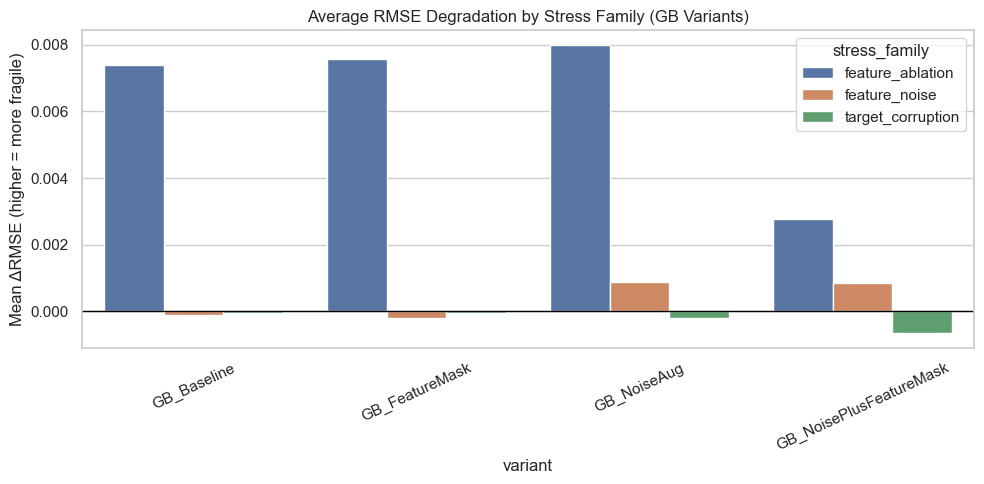

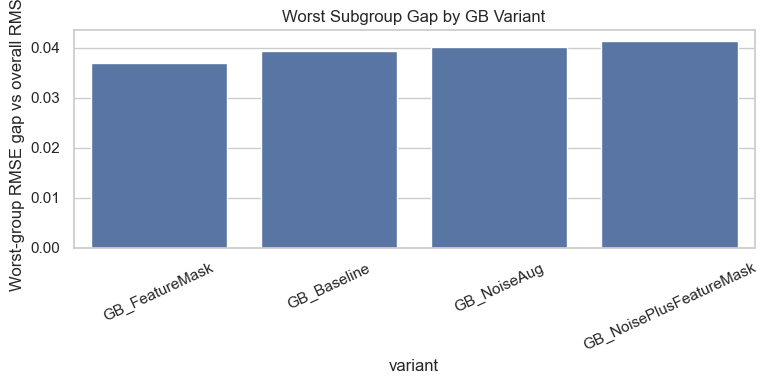

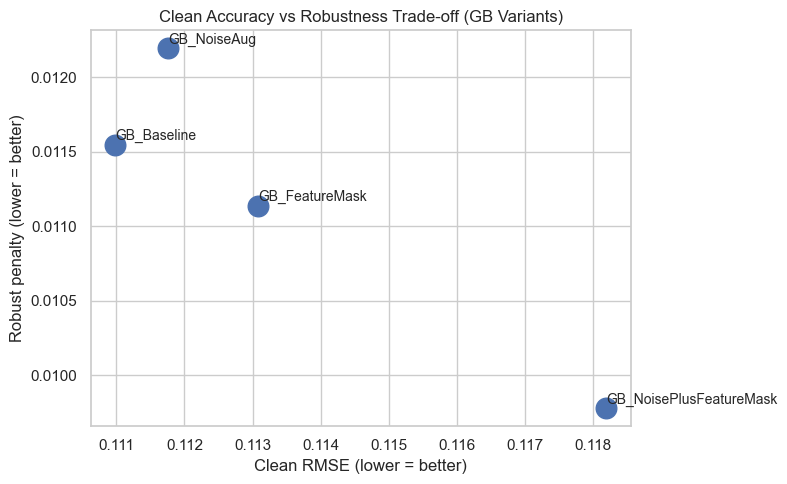

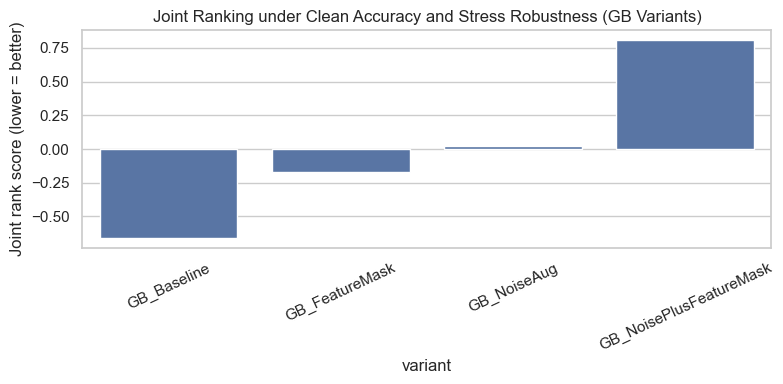

In [7]:

plt.figure(figsize=(10, 5))
sns.barplot(
    data=family_variant_summary_df,
    x="model",
    y="mean_delta_rmse",
    hue="stress_family",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average RMSE Degradation by Stress Family (GB Variants)")
plt.xlabel("variant")
plt.ylabel("Mean ΔRMSE (higher = more fragile)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "gb_variant_family_degradation.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=subgroup_gap_variant_df, x="model", y="worst_group_gap")
plt.title("Worst Subgroup Gap by GB Variant")
plt.xlabel("variant")
plt.ylabel("Worst-group RMSE gap vs overall RMSE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "gb_variant_worst_group_gap.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    gb_variant_summary["clean_rmse"],
    gb_variant_summary["robust_penalty_raw"],
    s=220,
)
for _, row in gb_variant_summary.iterrows():
    plt.text(row["clean_rmse"], row["robust_penalty_raw"] + 0.00003, row["model"], fontsize=10)
plt.title("Clean Accuracy vs Robustness Trade-off (GB Variants)")
plt.xlabel("Clean RMSE (lower = better)")
plt.ylabel("Robust penalty (lower = better)")
plt.tight_layout()
plt.savefig(FIG_DIR / "gb_variant_tradeoff.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=gb_variant_summary, x="model", y="joint_rank_score")
plt.title("Joint Ranking under Clean Accuracy and Stress Robustness (GB Variants)")
plt.xlabel("variant")
plt.ylabel("Joint rank score (lower = better)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "gb_variant_joint_rank.png", dpi=200, bbox_inches="tight")
plt.show()



## Final selection and save-out

Read the result in a disciplined way:
- if a robustness intervention wins, that is meaningful;
- if the baseline still wins, that also means something real;
- the goal is to **learn which targeted training design actually pays off**, not to declare intervention a success in advance.


In [8]:

final_variant_df = gb_variant_summary.head(1).copy()
final_variant_name = gb_variant_summary.iloc[0]["model"]
final_variant_model = fitted_variant_models[final_variant_name]

final_variant_df.to_csv(TABLE_DIR / "final_gb_variant_record.csv", index=False)
joblib.dump(final_variant_model, MODEL_DIR / "final_gb_variant.joblib")

print("Final selected variant:", final_variant_name)
display(final_variant_df)


Final selected variant: GB_Baseline


,rank,model,test,clean_rmse,clean_mae,clean_r2,feature_ablation,feature_noise,target_corruption,worst_group_rmse,best_group_rmse,mean_group_rmse,worst_group_gap,robust_penalty_raw,RobustScore,joint_rank_score
0,1,GB_Baseline,clean,0.110983,0.073427,0.918405,0.007386,-0.000113,-0.000047,0.150402,0.08186,0.106238,0.039419,0.01155,-0.01155,-0.659124
